In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
"""
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
"""
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

"\nfor dirname, _, filenames in os.walk('/kaggle/input'):\n    for filename in filenames:\n        print(os.path.join(dirname, filename))\n"

Number of normal images: 3000
Number of glioma images: 3000
Number of meningioma images: 3000
Number of pituitary images: 3000
Total number of images: 12000
Image shape: (224, 224)


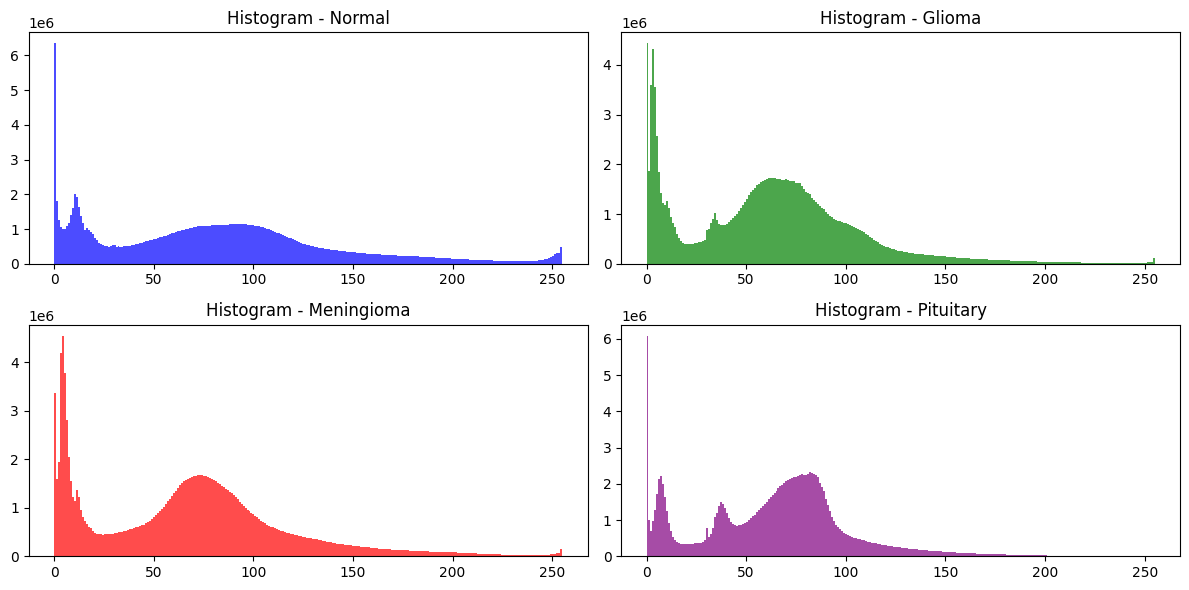

In [2]:
import os
import cv2  # Add this import statement
import matplotlib.pyplot as plt
import numpy as np
from glob import glob
from PIL import Image

# Set paths to the datasets
data_paths = {
    "normal": ["/kaggle/input/brain-tumor-mri-images-224x224/dataset/no_tumor"],
    "glioma": ["/kaggle/input/brain-tumor-mri-images-224x224/dataset/glioma_tumor"],
    "meningioma": ["/kaggle/input/brain-tumor-mri-images-224x224/dataset/meningioma_tumor"],
    "pituitary": ["/kaggle/input/brain-tumor-mri-images-224x224/dataset/pituitary_tumor"],
}

# Function to get statistics for a given class
def get_class_statistics(class_name, paths):
    total_samples = 0

    for path in paths:
        # Assuming each sample is stored in a separate file
        files = glob(os.path.join(path, '*'))
        total_samples += len(files)

    return {
        'class': class_name,
        'total_samples': total_samples,
        'files': files,  # Added to get the list of files for the class
    }

# Function to load and preprocess images
def load_images(paths):
    images = []
    for path in paths:
        for file in os.listdir(path):
            image_path = os.path.join(path, file)
            # Read the image in grayscale
            img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
            images.append(img)
    return np.array(images)

# Load images for each class
normal_images = load_images(data_paths["normal"])
glioma_images = load_images(data_paths["glioma"])
meningioma_images = load_images(data_paths["meningioma"])
pituitary_images = load_images(data_paths["pituitary"])

# Combine all images for overall analysis
all_images = np.concatenate([normal_images, glioma_images, meningioma_images, pituitary_images])

# Display basic statistics
print("Number of normal images:", len(normal_images))
print("Number of glioma images:", len(glioma_images))
print("Number of meningioma images:", len(meningioma_images))
print("Number of pituitary images:", len(pituitary_images))
print("Total number of images:", len(all_images))
print("Image shape:", all_images[0].shape)

# Generate and display histograms
plt.figure(figsize=(12, 6))

plt.subplot(2, 2, 1)
plt.hist(normal_images.flatten(), bins=256, color='blue', alpha=0.7, label='Normal')
plt.title('Histogram - Normal')

plt.subplot(2, 2, 2)
plt.hist(glioma_images.flatten(), bins=256, color='green', alpha=0.7, label='Glioma')
plt.title('Histogram - Glioma')

plt.subplot(2, 2, 3)
plt.hist(meningioma_images.flatten(), bins=256, color='red', alpha=0.7, label='Meningioma')
plt.title('Histogram - Meningioma')

plt.subplot(2, 2, 4)
plt.hist(pituitary_images.flatten(), bins=256, color='purple', alpha=0.7, label='Pituitary')
plt.title('Histogram - Pituitary')

plt.tight_layout()
plt.show()

In [3]:
from tensorflow.python.client import device_lib

print(device_lib.list_local_devices())

2024-02-25 20:24:18.738580: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-25 20:24:18.738679: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-25 20:24:18.865257: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


[name: "/device:CPU:0"
device_type: "CPU"
memory_limit: 268435456
locality {
}
incarnation: 16233298276591609485
xla_global_id: -1
, name: "/device:GPU:0"
device_type: "GPU"
memory_limit: 16274030592
locality {
  bus_id: 1
  links {
  }
}
incarnation: 8779858862152994386
physical_device_desc: "device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0"
xla_global_id: 416903419
]


Found 12000 images belonging to 4 classes.
Found 12000 images belonging to 4 classes.
Epoch 1/50


I0000 00:00:1708892682.665429      82 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 [==============================] - ETA: 0s - loss: 1.0485 - accuracy: 0.5397

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


375/375 [==============================] - 190s 485ms/step - loss: 1.0485 - accuracy: 0.5397 - val_loss: 0.7523 - val_accuracy: 0.6845
Epoch 2/50
375/375 [==============================] - 180s 480ms/step - loss: 0.8839 - accuracy: 0.6300 - val_loss: 0.6443 - val_accuracy: 0.7418
Epoch 3/50
375/375 [==============================] - 181s 484ms/step - loss: 0.8144 - accuracy: 0.6681 - val_loss: 0.6227 - val_accuracy: 0.7402
Epoch 4/50
375/375 [==============================] - 181s 482ms/step - loss: 0.7724 - accuracy: 0.6840 - val_loss: 0.5721 - val_accuracy: 0.7644
Epoch 5/50
375/375 [==============================] - 183s 487ms/step - loss: 0.7382 - accuracy: 0.6963 - val_loss: 0.5586 - val_accuracy: 0.7696
Epoch 6/50
375/375 [==============================] - 182s 486ms/step - loss: 0.7076 - accuracy: 0.7153 - val_loss: 0.5479 - val_accuracy: 0.7762
Epoch 7/50
375/375 [==============================] - 183s 488ms/step - loss: 0.6900 - accuracy: 0.7197 - val_loss: 0.5024 - val_accura

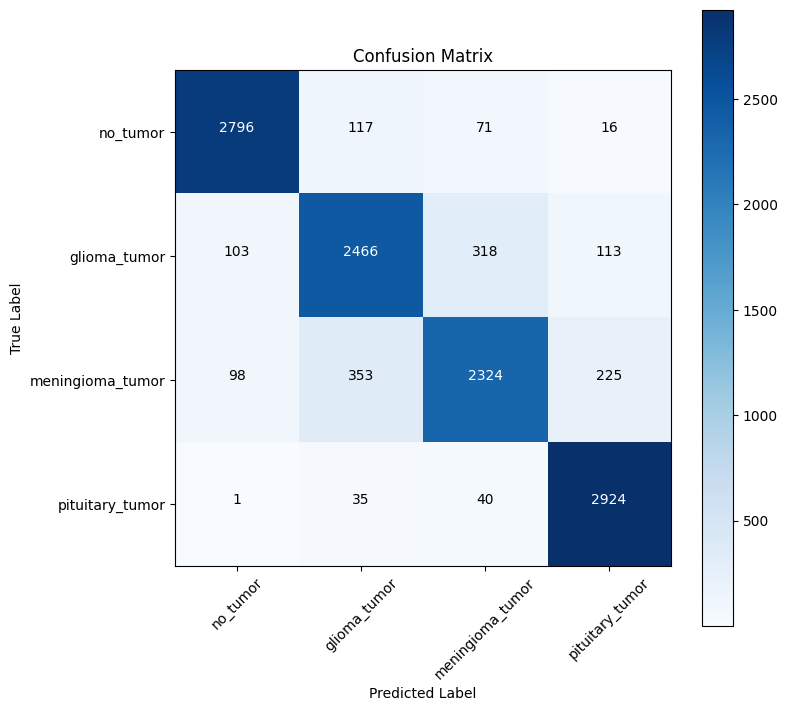

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.applications import VGG16
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

# Set paths
base_path = "/kaggle/input/brain-tumor-mri-images-224x224/dataset"
classes = ["no_tumor", "glioma_tumor", "meningioma_tumor", "pituitary_tumor"]

# 1. Data Loading and Augmentation using ImageDataGenerator
image_size = (224, 224)  # VGG16 input size
batch_size = 32

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    base_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',  
    classes=classes,
    shuffle=True,
    seed=42
)

# Create a separate validation generator
validation_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = validation_datagen.flow_from_directory(
    base_path,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    classes=classes,
    shuffle=False,  # No need to shuffle validation data
    seed=42
)

# 2. Model Selection - Use VGG16
# Manually download the weights file and upload it to your Kaggle environment
weights_path = "/kaggle/input/vgg-16/keras/vgg16/1/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5"

base_model = VGG16(weights=weights_path, include_top=False, input_shape=(224, 224, 3))

model = Sequential()
model.add(base_model)
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(4, activation='softmax')) 

# Freeze the weights of the VGG16 base model
base_model.trainable = False

# 3. Model Training
# a. Loss Function
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# b. Training Process
epochs = 50  # Adjust as needed
checkpoint_path = "/kaggle/working/model.h5"
checkpoint = ModelCheckpoint(checkpoint_path, save_best_only=True)

# Add EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

history = model.fit(train_generator, epochs=epochs, validation_data=validation_generator, callbacks=[checkpoint, early_stopping])

# Print training history
print(history.history)

# 4. Model Evaluation
# a. Metrics
test_loss, test_acc = model.evaluate(validation_generator)
print(f"Test Accuracy: {test_acc}")

# b. Confusion Matrix
y_test = validation_generator.classes
y_pred = model.predict(validation_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

conf_matrix = confusion_matrix(y_test, y_pred_classes)
print("Confusion Matrix:")
print(conf_matrix)

# Additional evaluation metrics and visualization

# a. Metrics (Continued)
classification_rep = classification_report(y_test, y_pred_classes, target_names=classes)
print("Classification Report:")
print(classification_rep)

# b. Confusion Matrix (Continued)
# Visualization of Confusion Matrix
plt.figure(figsize=(8, 8))
plt.imshow(conf_matrix, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')

for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(j, i, str(conf_matrix[i, j]), horizontalalignment="center", color="white" if conf_matrix[i, j] > conf_matrix.max() / 2 else "black")

plt.show()

----------------------

Epoch 1/20


2024-02-25 22:57:23.176864: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1/dropout_1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


304/304 [==============================] - 51s 138ms/step - loss: 2.1117 - accuracy: 0.2471 - val_loss: 1.4030 - val_accuracy: 0.2343
Epoch 2/20
304/304 [==============================] - 38s 125ms/step - loss: 1.3865 - accuracy: 0.2458 - val_loss: 1.4029 - val_accuracy: 0.2343
Epoch 3/20
304/304 [==============================] - 38s 125ms/step - loss: 1.3866 - accuracy: 0.2494 - val_loss: 1.4033 - val_accuracy: 0.2352
Epoch 4/20
304/304 [==============================] - 38s 125ms/step - loss: 1.3867 - accuracy: 0.2473 - val_loss: 1.4356 - val_accuracy: 0.2278
Epoch 5/20
304/304 [==============================] - 38s 125ms/step - loss: 1.3865 - accuracy: 0.2480 - val_loss: 1.4707 - val_accuracy: 0.2593
Epoch 6/20
304/304 [==============================] - 38s 125ms/step - loss: 1.3867 - accuracy: 0.2477 - val_loss: 1.4729 - val_accuracy: 0.2417
Epoch 7/20
304/304 [==============================] - 38s 125ms/step - loss: 1.3866 - accuracy: 0.2425 - val_loss: 1.4742 - val_accuracy: 0.2

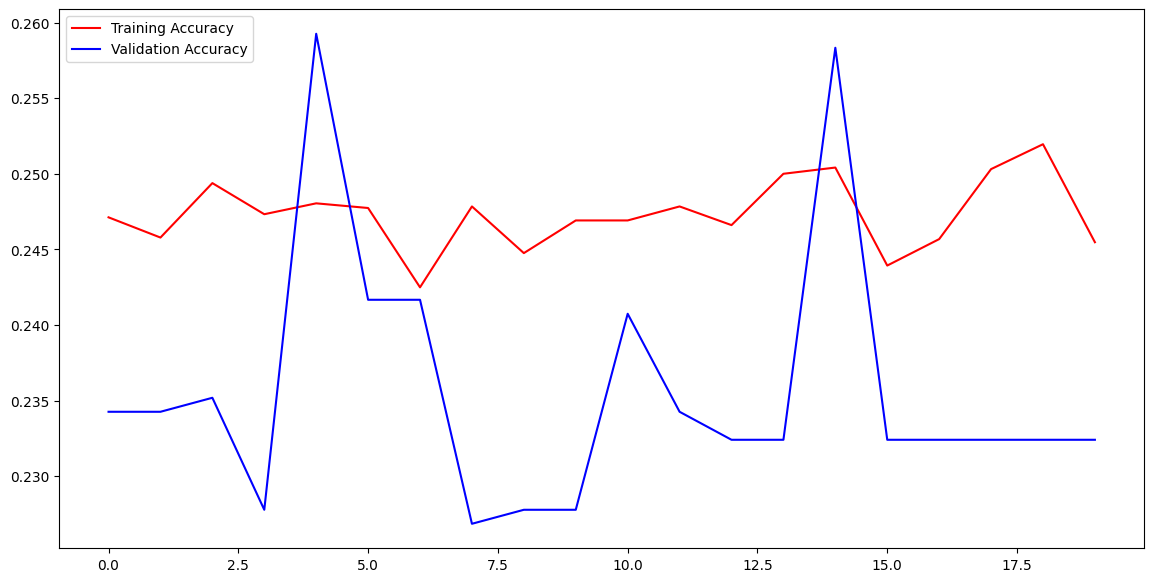

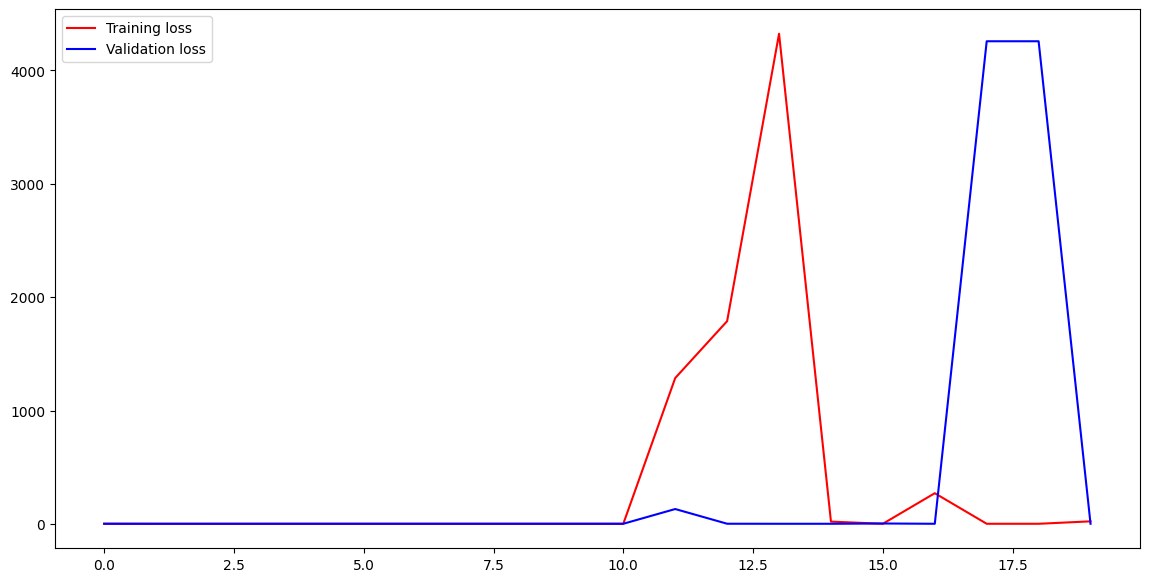

In [5]:
import os
import numpy as np
import cv2
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, MaxPooling2D, Dropout
import matplotlib.pyplot as plt

# Set paths
base_path = "/kaggle/input/brain-tumor-mri-images-224x224/dataset"
classes = ["no_tumor", "glioma_tumor", "meningioma_tumor", "pituitary_tumor"]

data = []
image_size = 224
labels = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

# Extracting labels based on the number of samples in data
y_labels = []
for label in labels:
    folderPath = os.path.join('/kaggle/input/brain-tumor-mri-images-224x224/dataset', label)
    num_samples = len(os.listdir(folderPath))
    y_labels.extend([label] * num_samples)

# Convert labels to numerical indices
y_labels_new = [labels.index(label) for label in y_labels]
y_labels_categorical = tf.keras.utils.to_categorical(y_labels_new)

# Load images into data array
for label in labels:
    folderPath = os.path.join('/kaggle/input/brain-tumor-mri-images-224x224/dataset', label)
    for image_name in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath, image_name))
        img = cv2.resize(img, (image_size, image_size))
        data.append(img)

data = np.array(data)

# Split the data and labels
X_train, X_test, y_train, y_test = train_test_split(data, y_labels_categorical, test_size=0.1, random_state=101)

# Build the model
model = Sequential()
model.add(Conv2D(32,(3,3),activation = 'relu',input_shape=(224,224,3)))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(Dropout(0.3))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(Conv2D(256,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(512,activation = 'relu'))
model.add(Dense(512,activation = 'relu'))
model.add(Dropout(0.3))
model.add(Dense(4,activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=20, validation_split=0.1)

# Visualize training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))
fig = plt.figure(figsize=(14, 7))
plt.plot(epochs, acc, 'r', label="Training Accuracy")
plt.plot(epochs, val_acc, 'b', label="Validation Accuracy")
plt.legend(loc='upper left')
plt.show()

loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))
fig = plt.figure(figsize=(14, 7))
plt.plot(epochs, loss, 'r', label="Training loss")
plt.plot(epochs, val_loss, 'b', label="Validation loss")
plt.legend(loc='upper left')
plt.show()
